In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install transformers datasets scikit-learn matplotlib tqdm scipy

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp311-cp311-win_amd64.whl (2449.4 MB)
  Using cached https://download.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp311-cp311-win_amd64.whl (6.1 MB)
  Using cached https://download.pytorch.org/whl/cu121/torchaudio-2.5.1%2Bcu121-cp311-cp311-win_amd64.whl (4.1 MB)
  Using cached filelock-3.20.0-py3-none-any.whl.metadata (2.1 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached https://download.pytorch.org/whl/jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2025.12.0-py3-none-any.whl.metadata (10 kB)
  Using cached sympy-1.13.1-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached pillow-12.0.0-cp311-cp311-win_amd64.whl.metadata (9.0 kB)
Using cached sympy-1.13.1-py3-

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Program Files\Python311\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached transformers-5.2.0-py3-none-any.whl.metadata (32 kB)
  Using cached datasets-4.5.0-py3-none-any.whl.metadata (19 kB)
  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.8 kB ? eta -:--:--
     ---------------------- --------------- 30.7/52.8 kB 330.3 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 458.0 kB/s eta 0:00:00
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached scipy-1.17.0-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached huggingface_hub-1.4.1-py3-none-any.whl.metadata (13 kB)
  Using cached pyyaml-6.0.3-cp311-cp311-win_amd64.whl.metadata (2.4 kB)
     ---------------------------------------- 0.0/41.5 kB ? eta -:--:--
     ---------------------------------------- 41.5/41.5 kB 2.

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

In [3]:


import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import accuracy_score, brier_score_loss
from sklearn.model_selection import train_test_split
from datasets import load_dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer
)
import scipy.stats as stats

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [4]:
# Load datasets
ag_news = load_dataset("ag_news")
yahoo = load_dataset("yahoo_answers_topics")

print(ag_news)
print(yahoo)

README.md: 0.00B [00:00, ?B/s]

C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Dell\.cache\huggingface\hub\datasets--ag_news. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

...

yahoo_answers_topics/train-00001-of-0000(…):   0%|          | 0.00/270M [00:00<?, ?B/s]

yahoo_answers_topics/test-00000-of-00001(…):   0%|          | 0.00/21.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1400000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/60000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
DatasetDict({
    train: Dataset({
        features: ['id', 'topic', 'question_title', 'question_content', 'best_answer'],
        num_rows: 1400000
    })
    test: Dataset({
        features: ['id', 'topic', 'question_title', 'question_content', 'best_answer'],
        num_rows: 60000
    })
})


In [5]:
# Use smaller subset for fast experimentation
train_data = ag_news['train'].shuffle(seed=42).select(range(10000))
test_data = ag_news['test'].shuffle(seed=42).select(range(2000))

shift_data = yahoo['test'].shuffle(seed=42).select(range(2000))

In [6]:
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["text"] if "text" in batch else batch["question_content"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_data = train_data.map(tokenize, batched=True)
test_data = test_data.map(tokenize, batched=True)
shift_data = shift_data.map(tokenize, batched=True)

columns = ['input_ids', 'attention_mask', 'label']
train_data.set_format(type='torch', columns=columns)
test_data.set_format(type='torch', columns=columns)
shift_data.set_format(type='torch', columns=['input_ids', 'attention_mask'])

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Dell\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [7]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=4
).to(device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=100,
    fp16=torch.cuda.is_available(),
    report_to="none"   # disables tensorboard / wandb
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=test_data
)

In [12]:
trainer.train()

C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss
1,0.288310,0.304703
2,0.202674,0.293801


TrainOutput(global_step=1250, training_loss=0.3058231338500977, metrics={'train_runtime': 2144.4052, 'train_samples_per_second': 9.327, 'train_steps_per_second': 0.583, 'total_flos': 662360616960000.0, 'train_loss': 0.3058231338500977, 'epoch': 2.0})

In [25]:
# ---- Multiclass Brier Score ----
def multiclass_brier(y_true, probs, num_classes):
    y_true_onehot = np.eye(num_classes)[y_true]
    return np.mean(np.sum((probs - y_true_onehot) ** 2, axis=1))


# ---- ECE ----
def compute_ece(probs, labels, n_bins=15):
    bins = np.linspace(0, 1, n_bins + 1)
    binids = np.digitize(np.max(probs, axis=1), bins) - 1

    ece = 0
    for i in range(n_bins):
        mask = binids == i
        if np.sum(mask) > 0:
            acc = np.mean(np.argmax(probs[mask], axis=1) == labels[mask])
            conf = np.mean(np.max(probs[mask], axis=1))
            ece += np.abs(acc - conf) * np.sum(mask) / len(labels)
    return ece


# ---- Main Evaluation Function ----
def evaluate(dataset):
    model.eval()
    all_probs = []
    all_labels = []

    loader = torch.utils.data.DataLoader(dataset, batch_size=32)

    with torch.no_grad():
        for batch in loader:
            inputs = {
                "input_ids": batch["input_ids"].to(device),
                "attention_mask": batch["attention_mask"].to(device)
            }
            outputs = model(**inputs)
            probs = F.softmax(outputs.logits, dim=1)
            all_probs.append(probs.cpu().numpy())

            if "label" in batch:
                all_labels.append(batch["label"].numpy())

    all_probs = np.vstack(all_probs)

    if len(all_labels) > 0:
        all_labels = np.concatenate(all_labels)

        acc = accuracy_score(all_labels, np.argmax(all_probs, axis=1))
        brier = multiclass_brier(all_labels, all_probs, num_classes=4)
        ece = compute_ece(all_probs, all_labels)

        return acc, brier, ece, all_probs, all_labels
    else:
        return None, None, None, all_probs, None

In [26]:
acc, brier, ece, probs_id, labels_id = evaluate(test_data)

print("In-Domain Accuracy:", acc)
print("In-Domain Brier:", brier)
print("In-Domain ECE:", ece)

In-Domain Accuracy: 0.9095
In-Domain Brier: 0.14626879567560158
In-Domain ECE: 0.04226753583550458


In [27]:
_, _, _, probs_shift, _ = evaluate(shift_data)

print("Shifted domain evaluated (no labels for calibration comparison).")

Shifted domain evaluated (no labels for calibration comparison).


In [28]:
def extract_embeddings(dataset):
    model.eval()
    embeddings = []

    loader = torch.utils.data.DataLoader(dataset, batch_size=32)

    with torch.no_grad():
        for batch in loader:
            inputs = {
                "input_ids": batch["input_ids"].to(device),
                "attention_mask": batch["attention_mask"].to(device)
            }
            outputs = model.distilbert(**inputs)
            cls_emb = outputs.last_hidden_state[:, 0, :]
            embeddings.append(cls_emb.cpu().numpy())

    return np.vstack(embeddings)

In [29]:
train_embeddings = extract_embeddings(train_data)
mu_train = np.mean(train_embeddings, axis=0)

print("Train embedding mean shape:", mu_train.shape)

Train embedding mean shape: (768,)


In [30]:
def compute_drift(embeddings, mu):
    return np.linalg.norm(embeddings - mu, axis=1)

# In-domain drift
test_embeddings = extract_embeddings(test_data)
drift_id = compute_drift(test_embeddings, mu_train)

# Shifted drift
shift_embeddings = extract_embeddings(shift_data)
drift_shift = compute_drift(shift_embeddings, mu_train)

print("Mean Drift (In-Domain):", np.mean(drift_id))
print("Mean Drift (Shifted):", np.mean(drift_shift))

Mean Drift (In-Domain): 14.764046
Mean Drift (Shifted): 14.506095


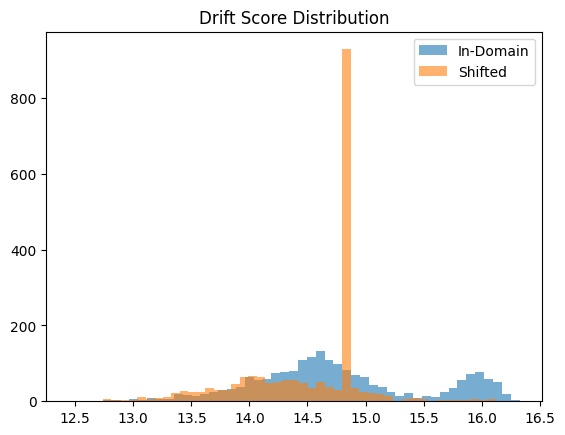

In [31]:
plt.hist(drift_id, bins=50, alpha=0.6, label="In-Domain")
plt.hist(drift_shift, bins=50, alpha=0.6, label="Shifted")
plt.legend()
plt.title("Drift Score Distribution")
plt.show()

In [32]:
def dynamic_temperature_scaling(logits, drift, T0=1.0, alpha=0.02):
    T = T0 + alpha * drift
    T = torch.tensor(T).unsqueeze(1).to(device)
    return logits / T

In [33]:
def evaluate_with_dts(dataset, drift_scores, T0=1.0, alpha=0.02):
    model.eval()
    all_probs = []
    all_labels = []

    loader = torch.utils.data.DataLoader(dataset, batch_size=32)

    idx = 0

    with torch.no_grad():
        for batch in loader:
            bs = batch["input_ids"].shape[0]

            inputs = {
                "input_ids": batch["input_ids"].to(device),
                "attention_mask": batch["attention_mask"].to(device)
            }

            outputs = model(**inputs)
            logits = outputs.logits

            drift_batch = drift_scores[idx:idx+bs]
            logits_scaled = dynamic_temperature_scaling(
                logits,
                drift_batch,
                T0,
                alpha
            )

            probs = F.softmax(logits_scaled, dim=1)
            all_probs.append(probs.cpu().numpy())

            if "label" in batch:
                all_labels.append(batch["label"].numpy())

            idx += bs

    all_probs = np.vstack(all_probs)
    all_labels = np.concatenate(all_labels)

    acc = accuracy_score(all_labels, np.argmax(all_probs, axis=1))
    brier = multiclass_brier(all_labels, all_probs, num_classes=4)
    ece = compute_ece(all_probs, all_labels)

    return acc, brier, ece

In [34]:
acc_dts, brier_dts, ece_dts = evaluate_with_dts(
    test_data,
    drift_id,
    T0=1.0,
    alpha=0.02
)

print("Baseline ECE:", ece)
print("DTS ECE:", ece_dts)

print("Baseline Brier:", brier)
print("DTS Brier:", brier_dts)

Baseline ECE: 0.04226753583550458
DTS ECE: 0.0352386949956417
Baseline Brier: 0.14626879567560158
DTS Brier: 0.1417557956382755


In [35]:
# Compute covariance matrix
cov = np.cov(train_embeddings, rowvar=False)

# Add small regularization for numerical stability
epsilon = 1e-5
cov += epsilon * np.eye(cov.shape[0])

# Invert covariance
cov_inv = np.linalg.inv(cov)

print("Covariance matrix computed.")

Covariance matrix computed.


In [36]:
def mahalanobis_drift(embeddings, mu, cov_inv):
    diff = embeddings - mu
    left = np.dot(diff, cov_inv)
    mahal = np.sqrt(np.sum(left * diff, axis=1))
    return mahal

In [37]:
drift_id_maha = mahalanobis_drift(test_embeddings, mu_train, cov_inv)
drift_shift_maha = mahalanobis_drift(shift_embeddings, mu_train, cov_inv)

print("Mahalanobis Drift (In-Domain):", np.mean(drift_id_maha))
print("Mahalanobis Drift (Shifted):", np.mean(drift_shift_maha))

Mahalanobis Drift (In-Domain): 27.699081590873806
Mahalanobis Drift (Shifted): 101.0203212989114


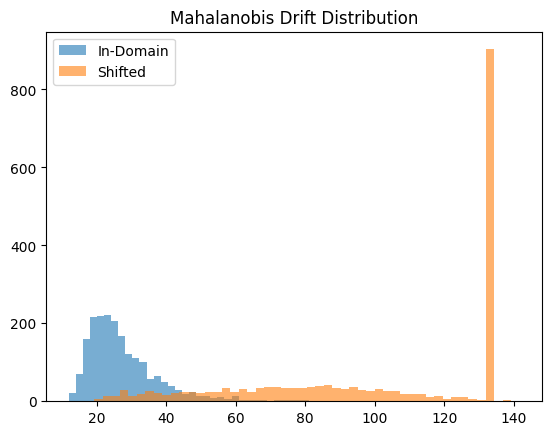

In [38]:
plt.hist(drift_id_maha, bins=50, alpha=0.6, label="In-Domain")
plt.hist(drift_shift_maha, bins=50, alpha=0.6, label="Shifted")
plt.legend()
plt.title("Mahalanobis Drift Distribution")
plt.show()

In [39]:
def normalize_drift(drift_scores):
    return (drift_scores - np.min(drift_scores)) / (
        np.max(drift_scores) - np.min(drift_scores) + 1e-8
    )

drift_id_norm = normalize_drift(drift_id_maha)
drift_shift_norm = normalize_drift(drift_shift_maha)

In [40]:
acc_dts_maha, brier_dts_maha, ece_dts_maha = evaluate_with_dts(
    test_data,
    drift_id_norm,
    T0=1.0,
    alpha=1.5   # larger alpha now since normalized
)

print("Baseline ECE:", ece)
print("Mahalanobis DTS ECE:", ece_dts_maha)

print("Baseline Brier:", brier)
print("Mahalanobis DTS Brier:", brier_dts_maha)

Baseline ECE: 0.04226753583550458
Mahalanobis DTS ECE: 0.01952683667248694
Baseline Brier: 0.14626879567560158
Mahalanobis DTS Brier: 0.14110137905865475


In [58]:
shift_data.set_format(
    type='torch',
    columns=['input_ids', 'attention_mask']
)

In [59]:
def evaluate_shift_confidence(dataset, drift_scores, T0=1.0, alpha=1.5):
    model.eval()
    all_conf = []
    all_conf_dts = []

    loader = torch.utils.data.DataLoader(dataset, batch_size=32)
    idx = 0

    with torch.no_grad():
        for batch in loader:
            bs = batch["input_ids"].shape[0]

            inputs = {
                "input_ids": batch["input_ids"].to(device),
                "attention_mask": batch["attention_mask"].to(device)
            }

            outputs = model(**inputs)
            logits = outputs.logits

            # Baseline
            probs = F.softmax(logits, dim=1)
            conf = torch.max(probs, dim=1).values

            # DTS
            drift_batch = drift_scores[idx:idx+bs]
            logits_dts = dynamic_temperature_scaling(logits, drift_batch, T0, alpha)
            probs_dts = F.softmax(logits_dts, dim=1)
            conf_dts = torch.max(probs_dts, dim=1).values

            all_conf.extend(conf.cpu().numpy())
            all_conf_dts.extend(conf_dts.cpu().numpy())

            idx += bs

    return np.array(all_conf), np.array(all_conf_dts)

In [60]:
conf_shift, conf_shift_dts = evaluate_shift_confidence(
    shift_data,
    drift_shift_norm
)

print("Shift Mean Confidence (Baseline):", np.mean(conf_shift))
print("Shift Mean Confidence (DTS):", np.mean(conf_shift_dts))

Shift Mean Confidence (Baseline): 0.5616729
Shift Mean Confidence (DTS): 0.47654253983854006


In [61]:
from scipy.stats import pearsonr

corr_baseline, p_baseline = pearsonr(drift_shift_norm, conf_shift)
corr_dts, p_dts = pearsonr(drift_shift_norm, conf_shift_dts)

print("Baseline Drift-Confidence Correlation:", corr_baseline)
print("Baseline p-value:", p_baseline)

print("DTS Drift-Confidence Correlation:", corr_dts)
print("DTS p-value:", p_dts)

Baseline Drift-Confidence Correlation: -0.930993585358156
Baseline p-value: 0.0
DTS Drift-Confidence Correlation: -0.9503693513118407
DTS p-value: 0.0


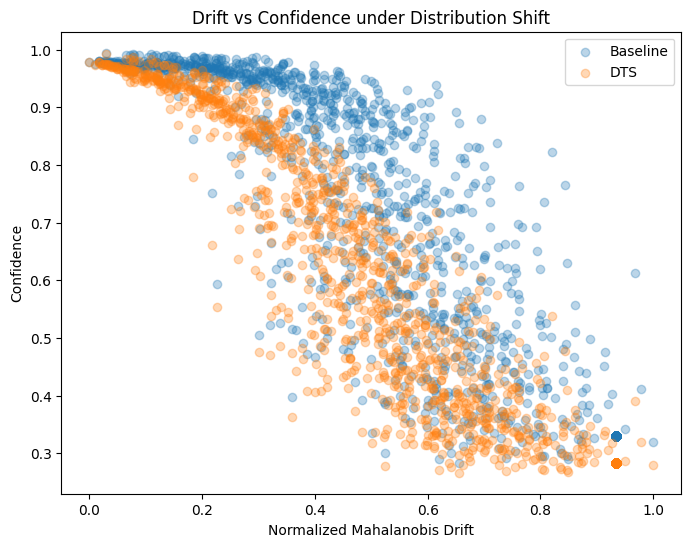

In [62]:
plt.figure(figsize=(8,6))
plt.scatter(drift_shift_norm, conf_shift, alpha=0.3, label="Baseline")
plt.scatter(drift_shift_norm, conf_shift_dts, alpha=0.3, label="DTS")
plt.xlabel("Normalized Mahalanobis Drift")
plt.ylabel("Confidence")
plt.legend()
plt.title("Drift vs Confidence under Distribution Shift")
plt.show()

In [63]:
# Top 30% drift threshold
threshold = np.percentile(drift_shift_norm, 70)

high_drift_mask = drift_shift_norm >= threshold

baseline_high = np.mean(conf_shift[high_drift_mask])
dts_high = np.mean(conf_shift_dts[high_drift_mask])

print("High Drift Mean Confidence (Baseline):", baseline_high)
print("High Drift Mean Confidence (DTS):", dts_high)

High Drift Mean Confidence (Baseline): 0.33016747
High Drift Mean Confidence (DTS): 0.2824828438300301


In [64]:
from scipy.stats import ttest_rel

t_stat, p_val = ttest_rel(conf_shift, conf_shift_dts)

print("Paired t-test statistic:", t_stat)
print("Paired t-test p-value:", p_val)

Paired t-test statistic: 61.841675732963076
Paired t-test p-value: 0.0


In [65]:
print("=== IN-DOMAIN ===")
print("ECE Baseline:", ece)
print("ECE DTS:", ece_dts_maha)

print("\n=== SHIFT DOMAIN ===")
print("Mean Confidence Baseline:", np.mean(conf_shift))
print("Mean Confidence DTS:", np.mean(conf_shift_dts))
print("High Drift Confidence Baseline:", baseline_high)
print("High Drift Confidence DTS:", dts_high)

=== IN-DOMAIN ===
ECE Baseline: 0.04226753583550458
ECE DTS: 0.01952683667248694

=== SHIFT DOMAIN ===
Mean Confidence Baseline: 0.5616729
Mean Confidence DTS: 0.47654253983854006
High Drift Confidence Baseline: 0.33016747
High Drift Confidence DTS: 0.2824828438300301


In [66]:
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1))

    def forward(self, logits):
        return logits / self.temperature

In [67]:
def collect_logits_labels(dataset):
    model.eval()
    logits_list = []
    labels_list = []

    loader = torch.utils.data.DataLoader(dataset, batch_size=32)

    with torch.no_grad():
        for batch in loader:
            inputs = {
                "input_ids": batch["input_ids"].to(device),
                "attention_mask": batch["attention_mask"].to(device)
            }
            outputs = model(**inputs)

            logits_list.append(outputs.logits)
            labels_list.append(batch["label"].to(device))

    return torch.cat(logits_list), torch.cat(labels_list)

val_logits, val_labels = collect_logits_labels(test_data)

In [68]:
def optimize_temperature(logits, labels):
    scaler = TemperatureScaler().to(device)
    optimizer = torch.optim.LBFGS([scaler.temperature], lr=0.01, max_iter=50)

    def loss_fn():
        optimizer.zero_grad()
        scaled_logits = scaler(logits)
        loss = F.cross_entropy(scaled_logits, labels)
        loss.backward()
        return loss

    optimizer.step(loss_fn)
    return scaler

temp_scaler = optimize_temperature(val_logits, val_labels)
print("Learned Temperature:", temp_scaler.temperature.item())

Learned Temperature: 1.0803656578063965


C:\Users\Dell\AppData\Roaming\Python\Python313\site-packages\torch\optim\lbfgs.py:457: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  loss = float(closure())


In [69]:
def evaluate_static_ts(dataset, scaler):
    model.eval()
    all_probs = []
    all_labels = []

    loader = torch.utils.data.DataLoader(dataset, batch_size=32)

    with torch.no_grad():
        for batch in loader:
            inputs = {
                "input_ids": batch["input_ids"].to(device),
                "attention_mask": batch["attention_mask"].to(device)
            }

            outputs = model(**inputs)
            logits_scaled = scaler(outputs.logits)

            probs = F.softmax(logits_scaled, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(batch["label"].numpy())

    all_probs = np.vstack(all_probs)
    all_labels = np.concatenate(all_labels)

    acc = accuracy_score(all_labels, np.argmax(all_probs, axis=1))
    brier = multiclass_brier(all_labels, all_probs, num_classes=4)
    ece = compute_ece(all_probs, all_labels)

    return acc, brier, ece

acc_ts, brier_ts, ece_ts = evaluate_static_ts(test_data, temp_scaler)

print("Static TS ECE:", ece_ts)

Static TS ECE: 0.034679396614432374


In [70]:
def reliability_diagram(probs, labels, title):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)

    bins = np.linspace(0, 1, 15)
    bin_centers = []
    accs = []
    confs = []

    for i in range(len(bins)-1):
        mask = (confidences >= bins[i]) & (confidences < bins[i+1])
        if np.sum(mask) > 0:
            acc = np.mean(predictions[mask] == labels[mask])
            conf = np.mean(confidences[mask])
            accs.append(acc)
            confs.append(conf)
            bin_centers.append((bins[i]+bins[i+1])/2)

    plt.plot(confs, accs, marker='o', label=title)

    return

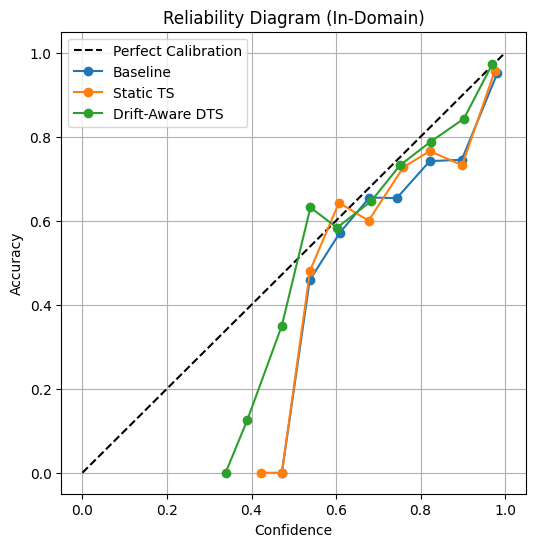

In [73]:
# ===============================
# FULL RELIABILITY DIAGRAM BLOCK
# ===============================

# --- Helper: Static TS probabilities ---
def get_probs_static_ts(dataset, scaler):
    model.eval()
    all_probs = []

    loader = torch.utils.data.DataLoader(dataset, batch_size=32)

    with torch.no_grad():
        for batch in loader:
            inputs = {
                "input_ids": batch["input_ids"].to(device),
                "attention_mask": batch["attention_mask"].to(device)
            }

            logits_scaled = scaler(model(**inputs).logits)
            probs = F.softmax(logits_scaled, dim=1)
            all_probs.append(probs.cpu().numpy())

    return np.vstack(all_probs)


# --- Helper: DTS probabilities ---
def get_probs_with_dts(dataset, drift_scores, T0=1.0, alpha=1.5):
    model.eval()
    all_probs = []

    loader = torch.utils.data.DataLoader(dataset, batch_size=32)
    idx = 0

    with torch.no_grad():
        for batch in loader:
            bs = batch["input_ids"].shape[0]

            inputs = {
                "input_ids": batch["input_ids"].to(device),
                "attention_mask": batch["attention_mask"].to(device)
            }

            outputs = model(**inputs)
            logits = outputs.logits

            drift_batch = drift_scores[idx:idx+bs]
            logits_scaled = dynamic_temperature_scaling(logits, drift_batch, T0, alpha)

            probs = F.softmax(logits_scaled, dim=1)
            all_probs.append(probs.cpu().numpy())

            idx += bs

    return np.vstack(all_probs)


# --- Reliability diagram function ---
def reliability_diagram(probs, labels, label_name):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)

    bins = np.linspace(0, 1, 15)
    bin_acc = []
    bin_conf = []

    for i in range(len(bins)-1):
        mask = (confidences >= bins[i]) & (confidences < bins[i+1])
        if np.sum(mask) > 0:
            acc = np.mean(predictions[mask] == labels[mask])
            conf = np.mean(confidences[mask])
            bin_acc.append(acc)
            bin_conf.append(conf)

    plt.plot(bin_conf, bin_acc, marker='o', label=label_name)


# ===============================
# COMPUTE PROBABILITIES
# ===============================

# Baseline probs (already computed earlier as probs_id)
# If not, recompute:
# acc_id, brier_id, ece_id, probs_id, labels_id = evaluate(test_data)

probs_ts = get_probs_static_ts(test_data, temp_scaler)
probs_dts = get_probs_with_dts(test_data, drift_id_norm)


# ===============================
# PLOT RELIABILITY DIAGRAM
# ===============================

plt.figure(figsize=(6,6))
plt.plot([0,1], [0,1], 'k--', label="Perfect Calibration")

reliability_diagram(probs_id, labels_id, "Baseline")
reliability_diagram(probs_ts, labels_id, "Static TS")
reliability_diagram(probs_dts, labels_id, "Drift-Aware DTS")

plt.xlabel("Confidence")
plt.ylabel("Accuracy")
plt.title("Reliability Diagram (In-Domain)")
plt.legend()
plt.grid(True)
plt.show()

In [74]:
# ===============================
# C1 — Alpha Sensitivity Analysis
# ===============================

alphas = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]

ece_results = []
brier_results = []

for a in alphas:
    acc_val, brier_val, ece_val = evaluate_with_dts(
        test_data,
        drift_id_norm,
        T0=1.0,
        alpha=a
    )
    
    ece_results.append(ece_val)
    brier_results.append(brier_val)
    
    print(f"Alpha = {a:.2f} | ECE = {ece_val:.6f} | Brier = {brier_val:.6f}")

Alpha = 0.00 | ECE = 0.042268 | Brier = 0.146269
Alpha = 0.50 | ECE = 0.036027 | Brier = 0.143756
Alpha = 1.00 | ECE = 0.024378 | Brier = 0.142040
Alpha = 1.50 | ECE = 0.019527 | Brier = 0.141101
Alpha = 2.00 | ECE = 0.021616 | Brier = 0.140898
Alpha = 3.00 | ECE = 0.028921 | Brier = 0.142454


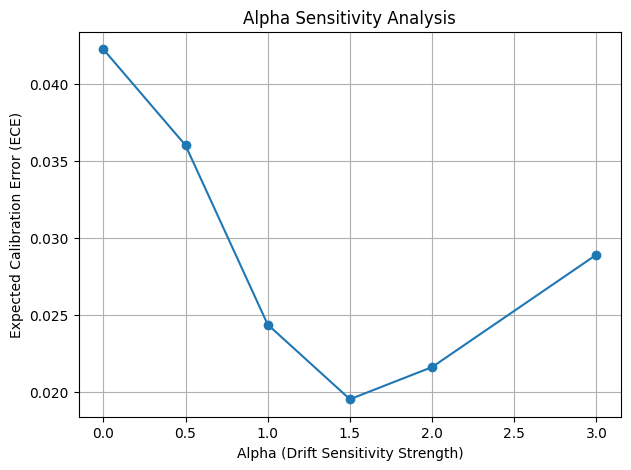

In [75]:
# ===============================
# C2 — Plot Alpha Sensitivity
# ===============================

plt.figure(figsize=(7,5))
plt.plot(alphas, ece_results, marker='o')
plt.xlabel("Alpha (Drift Sensitivity Strength)")
plt.ylabel("Expected Calibration Error (ECE)")
plt.title("Alpha Sensitivity Analysis")
plt.grid(True)
plt.show()

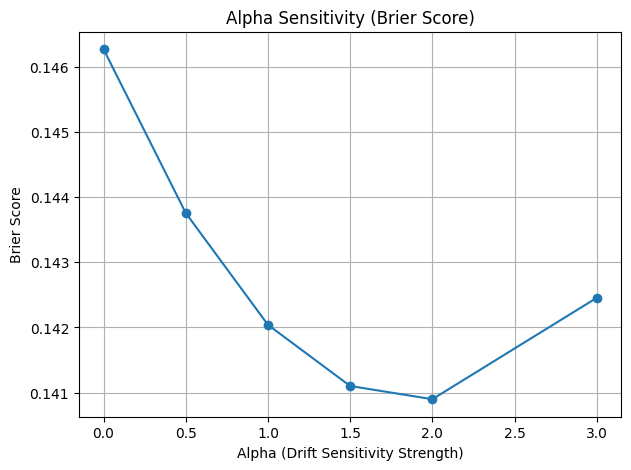

In [76]:
plt.figure(figsize=(7,5))
plt.plot(alphas, brier_results, marker='o')
plt.xlabel("Alpha (Drift Sensitivity Strength)")
plt.ylabel("Brier Score")
plt.title("Alpha Sensitivity (Brier Score)")
plt.grid(True)
plt.show()